Connecting to NOAA ERDDAP...
Download successful!
Downloaded: 624.88 KB

Data preview:
                   time   latitude  longitude  chlor_a
0  2021-06-02T12:00:00Z  25.020832  44.979170      NaN
1  2021-06-02T12:00:00Z  25.020832  45.187508      NaN
2  2021-06-02T12:00:00Z  25.020832  45.395840      NaN
3  2021-06-02T12:00:00Z  25.020832  45.604170      NaN
4  2021-06-02T12:00:00Z  25.020832  45.812508      NaN

Number of observations: 14065

Valid chlorophyll observations: 2757

Chlorophyll-a statistics:
count    2757.000000
mean        0.761481
std         3.561062
min         0.089878
25%         0.124532
50%         0.154797
75%         0.340628
max        71.991190
Name: chlor_a, dtype: float64


/Users/inside/miniforge3/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


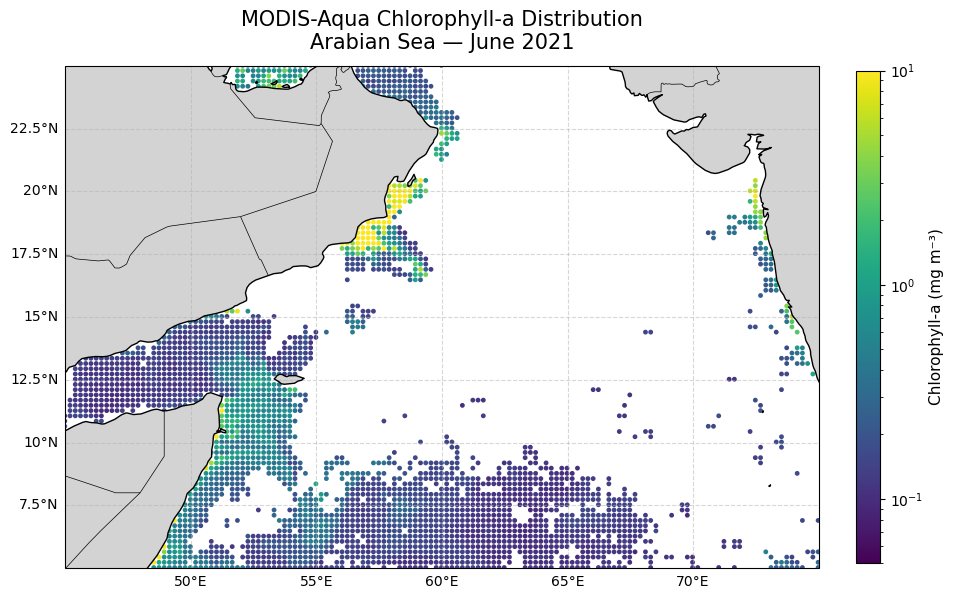

In [5]:
#Satellite-Based Assessment of Chlorophyll-a Variability in the Arabian Sea Using MODIS-Aqua Ocean Color Data

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from io import StringIO

# ============================================================
# 1. NOAA MODIS-Aqua 8-day chlorophyll-a dataset
# ============================================================

base_url = (
    "https://oceanwatch.pifsc.noaa.gov/erddap/griddap/"
    "aqua_chla_8d_2018_0.csv"
)


# ============================================================
# 2. Define Arabian Sea study area
# ============================================================

lat_min = 5
lat_max = 25

lon_min = 45
lon_max = 75


# ============================================================
# 3. Select an observation
# ============================================================

date = "2021-06-01T00:00:00Z"


# ============================================================
# 4. Request subset from ERDDAP
#
# Every 5th pixel is selected to reduce download size.
# ============================================================

query = (
    "?chlor_a"
    f"[({date})]"
    f"[({lat_min}):5:({lat_max})]"
    f"[({lon_min}):5:({lon_max})]"
)

url = base_url + query

print("Connecting to NOAA ERDDAP...")
print("Downloading Arabian Sea chlorophyll data...")


# ============================================================
# 5. Download data
# ============================================================

response = requests.get(
    url,
    timeout=120
)

response.raise_for_status()

print("Download successful!")
print(
    "Downloaded:",
    round(len(response.content) / 1024, 2),
    "KB"
)


# ============================================================
# 6. Read NOAA CSV
# ============================================================

df = pd.read_csv(
    StringIO(response.text),
    skiprows=[1]
)


print("\nData preview:")
print(df.head())

print("\nNumber of observations:", len(df))


# ============================================================
# 7. Remove missing and invalid values
# ============================================================

df["chlor_a"] = pd.to_numeric(
    df["chlor_a"],
    errors="coerce"
)

df["latitude"] = pd.to_numeric(
    df["latitude"],
    errors="coerce"
)

df["longitude"] = pd.to_numeric(
    df["longitude"],
    errors="coerce"
)


# Remove NaN values
df = df.dropna(
    subset=[
        "chlor_a",
        "latitude",
        "longitude"
    ]
)


# Chlorophyll must be positive for logarithmic scale
df = df[
    df["chlor_a"] > 0
]


print(
    "\nValid chlorophyll observations:",
    len(df)
)


# ============================================================
# 8. Basic statistics
# ============================================================

print("\nChlorophyll-a statistics:")
print(
    df["chlor_a"].describe()
)


# ============================================================
# 9. Create map
# ============================================================

fig = plt.figure(
    figsize=(12, 8)
)

ax = plt.axes(
    projection=ccrs.PlateCarree()
)


# ============================================================
# 10. Set Arabian Sea extent
# ============================================================

ax.set_extent(
    [
        lon_min,
        lon_max,
        lat_min,
        lat_max
    ],
    crs=ccrs.PlateCarree()
)


# ============================================================
# 11. Add geographic features
# ============================================================

ax.add_feature(
    cfeature.LAND,
    facecolor="lightgray",
    zorder=2
)

ax.add_feature(
    cfeature.COASTLINE,
    linewidth=1.0,
    zorder=3
)

ax.add_feature(
    cfeature.BORDERS,
    linewidth=0.5,
    zorder=3
)


# ============================================================
# 12. Plot chlorophyll-a
# ============================================================

scatter = ax.scatter(
    df["longitude"],
    df["latitude"],
    c=df["chlor_a"],
    s=12,
    cmap="viridis",

    norm=colors.LogNorm(
        vmin=0.05,
        vmax=10
    ),

    transform=ccrs.PlateCarree(),

    edgecolors="none"
)


# ============================================================
# 13. Gridlines
# ============================================================

gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    alpha=0.5
)

gl.top_labels = False
gl.right_labels = False


# ============================================================
# 14. Colorbar
# ============================================================

cbar = plt.colorbar(
    scatter,
    ax=ax,
    shrink=0.8,
    pad=0.04
)

cbar.set_label(
    "Chlorophyll-a (mg m⁻³)",
    fontsize=11
)


# ============================================================
# 15. Title
# ============================================================

plt.title(
    "MODIS-Aqua Chlorophyll-a Distribution\n"
    "Arabian Sea — June 2021",
    fontsize=15,
    pad=12
)


# ============================================================
# 16. Save figure
# ============================================================

plt.savefig(
    "arabian_sea_chlorophyll_june2021.png",
    dpi=300,
    bbox_inches="tight"
)


# ============================================================
# 17. Display
# ============================================================

plt.show()